In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('global_corporate_ghg_emissions_2022_2023.csv')
print('Shape:', df.shape)
df.head()

Shape: (508, 21)


,company_id,company_name,ticker,country,region,sector,industry,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,...,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,reporting_standard,data_source,third_party_verified,net_zero_target_year,notes,data_collection_date
0,GHG0001,Sasol,SOL,South Africa,Africa,Materials,Chemicals,2022,47.3,2.1,...,NaN,49.4,0.008386,5891.0,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,2050.0,Coal-to-liquid fuel — very high Scope 1,2024-01-01 to 2025-12-31
1,GHG0002,Eskom,—,South Africa,Africa,Utilities,Electric Power,2022,195.0,NaN,...,NaN,195.0,NaN,NaN,GHG Protocol (ZA),SouthAfricaGHGInv_2023,False,NaN,State-owned; coal dominant; financial distress,2024-01-01 to 2025-12-31
2,GHG0003,Woodside Energy,WDS,Australia,Asia-Pacific,Energy,E&P (LNG),2022,7.1,0.5,...,NaN,7.6,0.000452,16816.0,GHG Protocol,NGER_2023/CDP_2023,True,2050.0,NaN,2024-01-01 to 2025-12-31
3,GHG0004,Santos,STO,Australia,Asia-Pacific,Energy,E&P,2022,6.3,0.4,...,NaN,6.7,0.000923,7259.0,GHG Protocol,NGER_2023/CDP_2023,True,2040.0,NaN,2024-01-01 to 2025-12-31
4,GHG0005,BHP,BHP,Australia,Asia-Pacific,Materials,Mining,2022,14.9,3.4,...,NaN,18.3,0.000281,65098.0,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,2050.0,NaN,2024-01-01 to 2025-12-31


In [16]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
company_id                           0
company_name                         0
ticker                               0
country                              0
region                               0
sector                               0
industry                             0
reporting_year                       0
scope1_mt_co2e                       0
scope2_location_mt_co2e             28
scope2_market_mt_co2e              432
scope3_total_mt_co2e               485
scope1_plus_scope2_location_mt       0
emissions_intensity_mt_per_musd     64
revenue_usd_millions                64
reporting_standard                   0
data_source                          0
third_party_verified                 0
net_zero_target_year                56
notes                              382
data_collection_date                 0
dtype: int64


In [17]:
print('Target distribution:')
print(df['scope1_mt_co2e'].describe())
print(f'\nSkew: {df["scope1_mt_co2e"].skew():.2f}')

Target distribution:
count    508.000000
mean      20.066201
std       50.324981
min        0.050000
25%        1.200000
50%        5.150000
75%       17.825000
max      710.000000
Name: scope1_mt_co2e, dtype: float64

Skew: 7.36


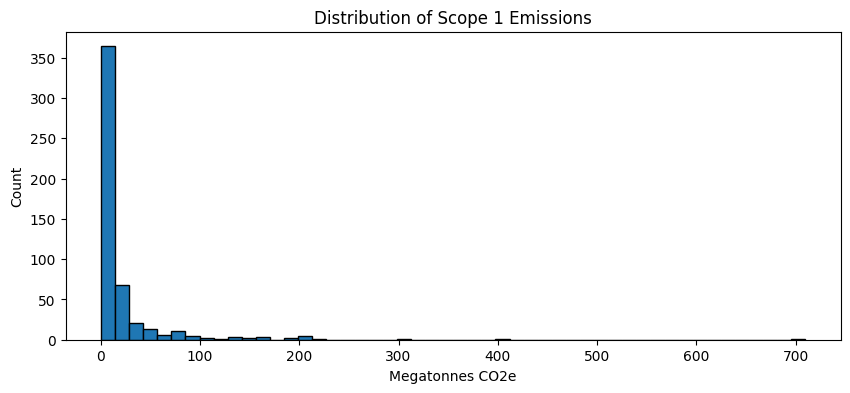

In [18]:
plt.figure(figsize=(10, 4))
plt.hist(df['scope1_mt_co2e'], bins=50, edgecolor='black')
plt.title('Distribution of Scope 1 Emissions')
plt.xlabel('Megatonnes CO2e')
plt.ylabel('Count')
plt.show()

In [19]:
drop_cols = [
    'company_id', 'company_name', 'ticker',
    'scope1_plus_scope2_location_mt',
    'emissions_intensity_mt_per_musd',
    'scope2_market_mt_co2e', 'scope3_total_mt_co2e',
    'notes', 'data_collection_date',
    'reporting_standard', 'data_source'
]

df = df.drop(columns=drop_cols)
print('Remaining columns:', list(df.columns))
print('Shape:', df.shape)

Remaining columns: ['country', 'region', 'sector', 'industry', 'reporting_year', 'scope1_mt_co2e', 'scope2_location_mt_co2e', 'revenue_usd_millions', 'third_party_verified', 'net_zero_target_year']
Shape: (508, 10)


In [20]:
print(f'Rows before: {len(df)}')
df = df.dropna(subset=['revenue_usd_millions'])
print(f'Rows after: {len(df)}')

Rows before: 508
Rows after: 444


In [21]:
industry_map = {
    'Integrated Oil & Gas': 'Oil & Gas', 'E&P': 'Oil & Gas', 'E&P (LNG)': 'Oil & Gas',
    'LNG': 'Oil & Gas', 'Oil Sands': 'Oil & Gas', 'Midstream': 'Oil & Gas',
    'Pipelines': 'Oil & Gas', 'Refining': 'Oil & Gas', 'Oilfield Services': 'Oil & Gas',
    'Natural Gas': 'Oil & Gas', 'Fuel Retail': 'Oil & Gas',
    'Coal': 'Coal', 'Coal Mining': 'Coal', 'Coal & Power': 'Coal',
    'Diversified Energy': 'Other Energy', 'Renewable Fuels': 'Other Energy',
    'Steel': 'Steel & Metals', 'Stainless Steel': 'Steel & Metals',
    'Steel Tubes': 'Steel & Metals', 'Aluminium': 'Steel & Metals',
    'Silicon/Alloys': 'Steel & Metals',
    'Mining': 'Mining', 'Mining & Commodities': 'Mining', 'Mining (Copper)': 'Mining',
    'Chemicals': 'Chemicals', 'Specialty Chemicals': 'Chemicals',
    'Agrochemicals': 'Chemicals', 'Fertilizers': 'Chemicals',
    'Industrial Gases': 'Chemicals', 'Chemicals & Cement': 'Chemicals',
    'Methanol': 'Chemicals', 'Paints & Coatings': 'Chemicals',
    'Coatings': 'Chemicals', 'Titanium Dioxide': 'Chemicals',
    'Specialty Materials': 'Chemicals', 'Advanced Materials': 'Chemicals',
    'Cement': 'Cement & Building', 'Building Materials': 'Cement & Building',
    'Building Products': 'Cement & Building', 'Aggregates': 'Cement & Building',
    'Paper': 'Paper & Packaging', 'Pulp & Paper': 'Paper & Packaging',
    'Forestry & Paper': 'Paper & Packaging', 'Packaging': 'Paper & Packaging',
    'Paper & Packaging': 'Paper & Packaging', 'Packaging & Tissue': 'Paper & Packaging',
    'Timber': 'Paper & Packaging',
    'Electric Power': 'Electric Power',
    'Gas & Power': 'Gas Utilities', 'Gas Distribution': 'Gas Utilities',
    'Gas & Renewables': 'Gas Utilities',
    'Renewables': 'Renewables', 'Offshore Wind': 'Renewables',
    'Hydroelectric': 'Renewables', 'Biomass Power': 'Renewables',
    'Nuclear Power': 'Renewables', 'District Energy': 'Renewables',
    'District Heating': 'Renewables', 'Transmission': 'Renewables',
    'Airlines': 'Airlines',
    'Shipping': 'Other Transport', 'Rail': 'Other Transport',
    'Logistics': 'Other Transport',
    'Automotive': 'Automotive', 'Auto Parts': 'Automotive',
    'E-Commerce': 'Consumer & Retail', 'Restaurants': 'Consumer & Retail',
    'Electronics': 'Consumer & Retail', 'Luxury': 'Consumer & Retail',
    'Tyre & Rubber': 'Consumer & Retail', 'Retail': 'Consumer & Retail',
    'Food': 'Food & Agriculture', 'Food & Beverage': 'Food & Agriculture',
    'Food & Dairy': 'Food & Agriculture', 'Food & Retail': 'Food & Agriculture',
    'Beverages': 'Food & Agriculture', 'Meat Processing': 'Food & Agriculture',
    'Agricultural Processing': 'Food & Agriculture', 'Agricultural Trading': 'Food & Agriculture',
    'Agri-Food': 'Food & Agriculture', 'Palm Oil': 'Food & Agriculture',
    'Horticulture': 'Food & Agriculture',
    'Personal Care': 'Consumer Products', 'Household Products': 'Consumer Products',
    'Aerospace & Defense': 'Industrials', 'Aerospace': 'Industrials',
    'Aerospace Engines': 'Industrials', 'Defense': 'Industrials',
    'Defense Electronics': 'Industrials', 'Simulation & Training': 'Industrials',
    'Heavy Machinery': 'Industrials', 'Heavy Engineering': 'Industrials',
    'Diversified Industrial': 'Industrials', 'Diversified Manufacturing': 'Industrials',
    'Automation': 'Industrials', 'Mining Equipment': 'Industrials',
    'Conglomerate': 'Industrials', 'Waste Management': 'Industrials',
    'Electrical Equipment': 'Industrials', 'Electrification': 'Industrials',
    'Elevators & Escalators': 'Industrials', 'Engines & Components': 'Industrials',
    'Green Hydrogen': 'Industrials', 'HVAC': 'Industrials',
    'Bearings': 'Industrials', 'Compressors & Pumps': 'Industrials',
    'Plastics Machinery': 'Industrials', 'Battery Recycling': 'Industrials',
    'Pharmaceuticals': 'Health Care', 'Biotechnology': 'Health Care',
    'Life Sciences': 'Health Care', 'Medical Devices': 'Health Care',
    'Contract Pharma': 'Health Care', 'Dialysis': 'Health Care',
    'Managed Care': 'Health Care',
    'Semiconductors': 'Technology', 'IT Services': 'Technology',
    'Software': 'Technology', 'Internet': 'Technology',
    'Consumer Electronics': 'Technology', 'Electronics Manufacturing': 'Technology',
    'PCs & Printers': 'Technology',
    'Banking': 'Financials', 'Insurance': 'Financials', 'Asset Management': 'Financials',
    'Real Estate': 'Real Estate', 'Real Estate Services': 'Real Estate',
    'Residential': 'Real Estate', 'Industrial REIT': 'Real Estate',
    'Retail REIT': 'Real Estate',
    'Telecom': 'Telecom',
}

df['industry_group'] = df['industry'].map(industry_map)
unmapped = df[df['industry_group'].isnull()]['industry'].unique()
print(f'Unmapped industries: {unmapped}')

Unmapped industries: []


In [22]:
print(df['industry_group'].value_counts())
df = df.drop(columns=['industry'])

industry_group
Oil & Gas             59
Electric Power        51
Chemicals             45
Industrials           40
Steel & Metals        34
Airlines              27
Health Care           22
Mining                20
Food & Agriculture    18
Technology            17
Automotive            16
Paper & Packaging     15
Cement & Building     13
Consumer & Retail     13
Gas Utilities         10
Other Transport        9
Telecom                8
Financials             8
Renewables             5
Real Estate            5
Coal                   4
Consumer Products      3
Other Energy           2
Name: count, dtype: int64


In [23]:
df['has_net_zero_target'] = df['net_zero_target_year'].notna().astype(int)
df['net_zero_target_year'] = df['net_zero_target_year'].fillna(df['net_zero_target_year'].median())

In [24]:
df['scope2_location_mt_co2e'] = df.groupby('sector')['scope2_location_mt_co2e'] \
    .transform(lambda x: x.fillna(x.median()))

df['scope2_location_mt_co2e'] = df['scope2_location_mt_co2e'].fillna(
    df['scope2_location_mt_co2e'].median()
)

In [25]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nShape: {df.shape}')

Missing values:
country                    0
region                     0
sector                     0
reporting_year             0
scope1_mt_co2e             0
scope2_location_mt_co2e    0
revenue_usd_millions       0
third_party_verified       0
net_zero_target_year       0
industry_group             0
has_net_zero_target        0
dtype: int64

Shape: (444, 11)


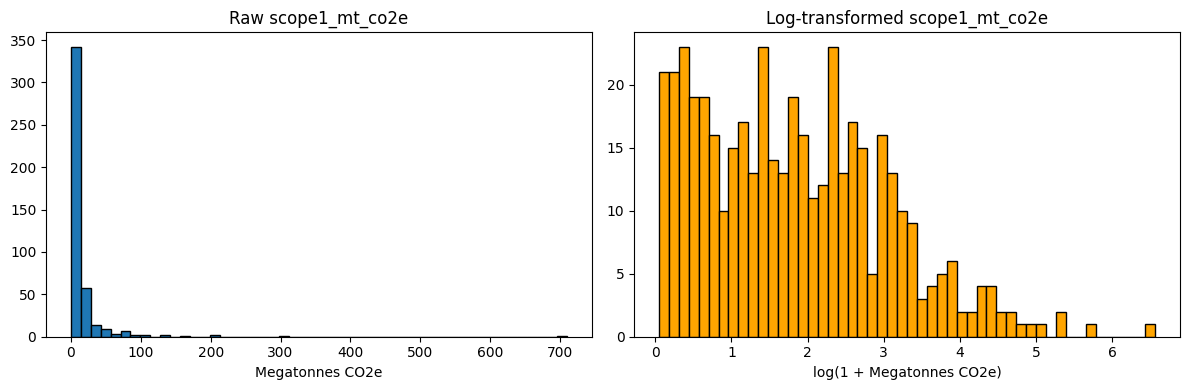

Skew before: 11.01
Skew after:  0.60


In [27]:
df['log_scope1'] = np.log1p(df['scope1_mt_co2e'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['scope1_mt_co2e'], bins=50, edgecolor='black')
axes[0].set_title('Raw scope1_mt_co2e')
axes[0].set_xlabel('Megatonnes CO2e')

axes[1].hist(df['log_scope1'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('Log-transformed scope1_mt_co2e')
axes[1].set_xlabel('log(1 + Megatonnes CO2e)')

plt.tight_layout()
plt.show()

print(f'Skew before: {df["scope1_mt_co2e"].skew():.2f}')
print(f'Skew after:  {df["log_scope1"].skew():.2f}')

In [28]:
X = df.drop(columns=['scope1_mt_co2e', 'log_scope1'])
y = df['log_scope1']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape: (444, 10)
Target shape: (444,)

Feature columns: ['country', 'region', 'sector', 'reporting_year', 'scope2_location_mt_co2e', 'revenue_usd_millions', 'third_party_verified', 'net_zero_target_year', 'industry_group', 'has_net_zero_target']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Training set: 355 rows
Test set:     89 rows


In [31]:
cat_cols = ['country', 'region', 'sector', 'industry_group']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = X_test[col].map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )
    encoders[col] = le
    print(f'{col}: {len(le.classes_)} categories encoded')

X_train['third_party_verified'] = X_train['third_party_verified'].astype(int)
X_test['third_party_verified'] = X_test['third_party_verified'].astype(int)

country: 41 categories encoded
region: 5 categories encoded
sector: 12 categories encoded
industry_group: 22 categories encoded


In [32]:
print('Target in features?', 'scope1_mt_co2e' in X_train.columns)
print('Nulls in X_train:', X_train.isnull().sum().sum())
print('Nulls in X_test:', X_test.isnull().sum().sum())
print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
X_train.head()

Target in features? False
Nulls in X_train: 0
Nulls in X_test: 0

X_train: (355, 10), y_train: (355,)
X_test:  (89, 10), y_test:  (89,)


,country,region,sector,reporting_year,scope2_location_mt_co2e,revenue_usd_millions,third_party_verified,net_zero_target_year,industry_group,has_net_zero_target
25,7,0,3,2022,2.3,43085.0,0,2050.0,14,1
94,19,0,8,2022,1.1,2050.0,1,2050.0,19,1
294,0,2,3,2022,0.6,16900.0,1,2050.0,14,0
292,39,1,11,2022,0.2,31696.0,1,2045.0,10,1
55,15,0,3,2022,0.6,3400.0,0,2038.0,14,1


In [33]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)

LinearRegression()

In [34]:
y_train_pred_base = baseline.predict(X_train)
y_test_pred_base = baseline.predict(X_test)

In [35]:
print('--- Baseline: Linear Regression ---')
print(f'Train R²:  {r2_score(y_train, y_train_pred_base):.4f}')
print(f'Test R²:   {r2_score(y_test, y_test_pred_base):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_base)):.4f}')
print(f'Test MAE:  {mean_absolute_error(y_test, y_test_pred_base):.4f}')

--- Baseline: Linear Regression ---
Train R²:  0.4262
Test R²:   0.4871
Test RMSE: 0.8958
Test MAE:  0.7128


In [36]:
cv_scores = cross_val_score(baseline, X_train, y_train, cv=5, scoring='r2')
print(f'5-Fold CV R² scores: {cv_scores.round(4)}')
print(f'Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}')

5-Fold CV R² scores: [0.3768 0.3315 0.3807 0.4824 0.221 ]
Mean CV R²: 0.3585 (+/- 0.0847


In [37]:
cv_scores = cross_val_score(baseline, X_train, y_train, cv=5, scoring='r2')
print(f'5-Fold CV R² scores: {cv_scores.round(4)}')
print(f'Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}')

5-Fold CV R² scores: [0.3768 0.3315 0.3807 0.4824 0.221 ]
Mean CV R²: 0.3585 (+/- 0.0847


In [38]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [39]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print('--- Random Forest ---')
print(f'Train R²:  {r2_score(y_train, y_train_pred_rf):.4f}')
print(f'Test R²:   {r2_score(y_test, y_test_pred_rf):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.4f}')
print(f'Test MAE:  {mean_absolute_error(y_test, y_test_pred_rf):.4f}')

--- Random Forest ---
Train R²:  0.9574
Test R²:   0.7514
Test RMSE: 0.6237
Test MAE:  0.4567


In [40]:
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f'5-Fold CV R² scores: {cv_scores_rf.round(4)}')
print(f'Mean CV R²: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')

5-Fold CV R² scores: [0.6687 0.6958 0.7031 0.7313 0.5664]
Mean CV R²: 0.6731 (+/- 0.0569)


In [43]:
"""
# Parameters for Random Forest:

n_estimators: 
    Specifies the number of trees in the forest. 
    Increasing the number of trees generally improves performance, but with diminishing returns.

max_depth: 
    Defines the maximum depth of each tree. 
    Shallower trees are simpler and less prone to overfitting, making this parameter a key control for overfitting.

min_samples_split: 
    The minimum number of samples required to split an internal node. 
    Higher values prevent the tree from creating splits based on very few data points, reducing overfitting.

min_samples_leaf: 
    The minimum number of samples required to be at a leaf node. 
    This ensures that leaf nodes represent a group of data points rather than a single data point.

max_features: 
    Specifies the number of features to consider when looking for the best split. 
    Using a subset of features introduces randomness, which helps reduce overfitting.
"""

'\n# Parameters for Random Forest:\n\nn_estimators: \n    Specifies the number of trees in the forest. \n    Increasing the number of trees generally improves performance, but with diminishing returns.\n\nmax_depth: \n    Defines the maximum depth of each tree. \n    Shallower trees are simpler and less prone to overfitting, making this parameter a key control for overfitting.\n\nmin_samples_split: \n    The minimum number of samples required to split an internal node. \n    Higher values prevent the tree from creating splits based on very few data points, reducing overfitting.\n\nmin_samples_leaf: \n    The minimum number of samples required to be at a leaf node. \n    This ensures that leaf nodes represent a group of data points rather than a single data point.\n\nmax_features: \n    Specifies the number of features to consider when looking for the best split. \n    Using a subset of features introduces randomness, which helps reduce overfitting.\n'

In [41]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.75]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(f'Best CV R²: {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

226764.46s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/arjunsundaram/Desktop/PersonalCodingProjects/ml_learning/GreenhouseGasEmissions/.venv/lib/python3.9/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/arjunsundaram/Desktop/PersonalCodingProjects/ml_learning/GreenhouseGasEmissions/.venv/lib/python3.9/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
TypeError: a bytes-like object is required, not 'str'


Best CV R²: 0.7049
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}


In [44]:
best_rf = search.best_estimator_

y_train_pred_tuned = best_rf.predict(X_train)
y_test_pred_tuned = best_rf.predict(X_test)

print('--- Tuned Random Forest ---')
print(f'Train R²:  {r2_score(y_train, y_train_pred_tuned):.4f}')
print(f'Test R²:   {r2_score(y_test, y_test_pred_tuned):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_tuned)):.4f}')
print(f'Test MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.4f}')

--- Tuned Random Forest ---
Train R²:  0.9515
Test R²:   0.7579
Test RMSE: 0.6155
Test MAE:  0.4543


In [45]:
print('=== Model Comparison ===')
print(f'{"Model":<25} {"Train R²":<12} {"Test R²":<12} {"CV R²":<12}')
print('-' * 60)
print(f'{"Linear Regression":<25} {r2_score(y_train, y_train_pred_base):<12.4f} {r2_score(y_test, y_test_pred_base):<12.4f} {cv_scores.mean():<12.4f}')
print(f'{"Random Forest (default)":<25} {r2_score(y_train, y_train_pred_rf):<12.4f} {r2_score(y_test, y_test_pred_rf):<12.4f} {cv_scores_rf.mean():<12.4f}')
print(f'{"Random Forest (tuned)":<25} {r2_score(y_train, y_train_pred_tuned):<12.4f} {r2_score(y_test, y_test_pred_tuned):<12.4f} {search.best_score_:<12.4f}')

=== Model Comparison ===
Model                     Train R²     Test R²      CV R²       
------------------------------------------------------------
Linear Regression         0.4262       0.4871       0.3585      
Random Forest (default)   0.9574       0.7514       0.6731      
Random Forest (tuned)     0.9515       0.7579       0.7049      


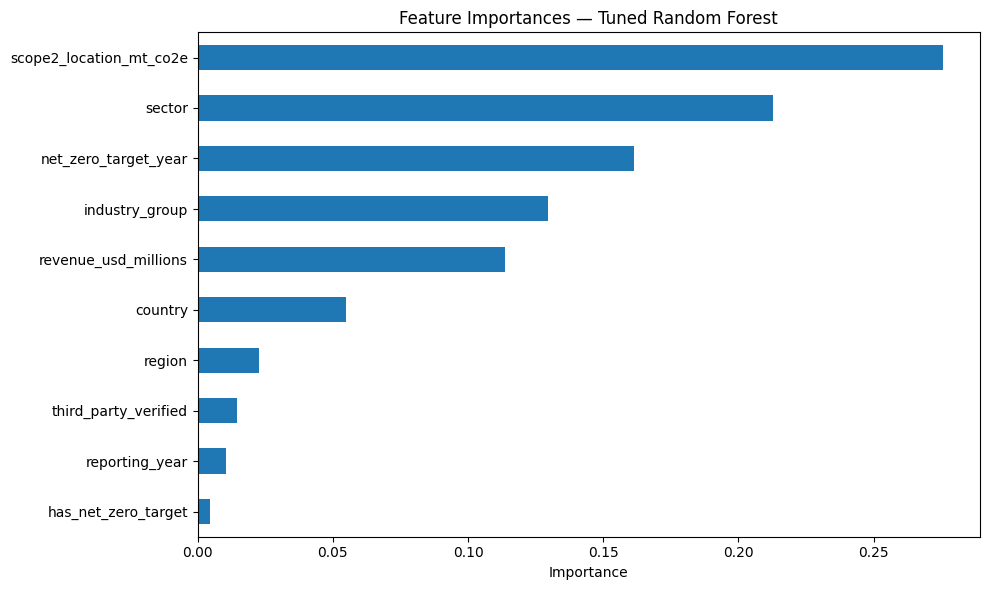

In [46]:
importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Feature Importances — Tuned Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()